# Revision exercises

These exercises are an occasion to consolidate some techniues and see some of the potential ahead (e.g. using scipy).)

Each exercise has a short description, a **PROVIDED** code cell with data or setup you should not modify, and a **COMPLETE THIS CODE** cell where you write your solution.

## Exercise 1: Customising Plot Styles

**Objective**: Practice using matplotlib's colour, linestyle, and marker options to produce a well-formatted figure.

Matplotlib supports a wide range of style options:

- *Colours*: named strings (`"red"`, `"midnightblue"`), greyscale fractions (`"0.5"`), hex codes, or default cycle colours (`"C0"`, `"C1"`, `"C2"`). See the [colour reference](https://matplotlib.org/stable/gallery/color/named_colors.html).
- *Linestyles*: `"-"` (solid), `"--"` (dashed), `":"` (dotted), `"-."` (dash-dot). See the [linestyle gallery](https://matplotlib.org/stable/gallery/lines_bars_and_markers/linestyles.html).
- *Markers*: `"o"` (circle), `"x"` (cross), `"."` (point), `"^"` (triangle), etc. See the [marker reference](https://matplotlib.org/stable/api/markers_api.html).

**Task**: The provided cell below defines three wave signals. Create a single figure with all three curves on the same axes:

1. `y1` — red, dashed line with circle markers (`"o"`)
2. `y2` — midnightblue, solid line, no markers
3. `y3` — grey (`"0.5"`), dotted line with cross markers (`"x"`)

Add a title, x-label, y-label, and a legend.

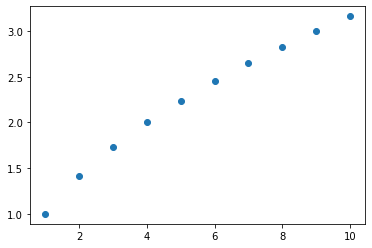

In [ ]:
# PROVIDED
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 2 * np.pi, 50)
y1 = np.sin(x)
y2 = np.cos(x)
y3 = np.sin(2 * x)

In [ ]:
## COMPLETE THIS CODE

fig, ax = plt.subplots()

# TODO: plot y1 as a red dashed line with circle markers
ax.plot(...)

# TODO: plot y2 as a midnightblue solid line with no markers
ax.plot(...)

# TODO: plot y3 as a grey ("0.5") dotted line with cross markers
ax.plot(...)

# TODO: add a title, x-label ("x"), y-label ("y"), and legend


## Exercise 2: Saving Figures

**Objective**: Practice saving matplotlib and pandas figures to file using `fig.savefig()`.

The file format is determined by the extension you provide:

- `.png` — PNG raster image (default)
- `.pdf` — PDF vector format (ideal for publications)
- Other formats: `.eps`, `.ps`, `.svg`

**Task**:

1. The provided cell creates a matplotlib figure. Save it as both `"sqrt_plot.png"` and `"sqrt_plot.pdf"`.
2. Then practice saving a pandas plot using two different approaches:
   - **Approach 1**: Create a `fig, ax` pair with `plt.subplots()`, pass `ax` to `df.plot(ax=ax)`, then save via `fig.savefig()`.
   - **Approach 2**: Don't create a `fig` explicitly — capture the Axes returned by `ax = df.plot()`, retrieve the Figure with `ax.get_figure()`, then save.

<AxesSubplot:>

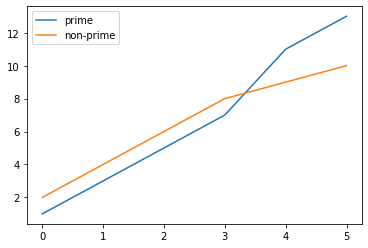

In [ ]:
# PROVIDED
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(1, 11)
y = np.sqrt(x)

fig, ax = plt.subplots()
ax.scatter(x, y)
ax.set_xlabel("x")
ax.set_ylabel("sqrt(x)")
ax.set_title("Square root function")
plt.show()

In [ ]:
## COMPLETE THIS CODE

# TODO: save the figure above as a PNG file named "sqrt_plot.png"

# TODO: save the same figure as a PDF file named "sqrt_plot.pdf"


**Approach 1 (Pandas)**: Pass an Axes object to `df.plot()` so you already hold the `fig` handle:

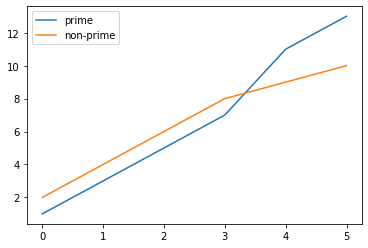

In [ ]:
## COMPLETE THIS CODE

import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame({"prime": [2, 3, 5, 7, 11, 13], "non-prime": [1, 4, 6, 8, 9, 10]})

# TODO: create a fig, ax pair with plt.subplots()

# TODO: call df.plot(ax=ax) to produce the plot

# TODO: save the figure as "primes_approach1.png"


**Approach 2 (Pandas)**: Let `df.plot()` return the Axes, then retrieve the Figure from it:

In [ ]:
## COMPLETE THIS CODE

import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame({"prime": [2, 3, 5, 7, 11, 13], "non-prime": [1, 4, 6, 8, 9, 10]})

# TODO: call df.plot() and capture the returned Axes object in a variable `ax`

# TODO: retrieve the Figure from the Axes using .get_figure()

# TODO: save the figure as "primes_approach2.png"


## Exercise 3: Index-based Scatter Plot with Pandas

**Objective**: Learn how to create scatter-like plots in pandas when the x-axis should be the DataFrame index.

`df.plot.scatter()` requires two column names and cannot use the index as the x-axis. To produce a scatter-like appearance (markers, no connecting line) against the index, use `df.plot.line()` with two key parameters:

- `marker=` — any marker symbol, e.g. `"o"`, `"x"`, `"."`
- `linestyle="None"` (or `" "` or `""`) — suppresses the connecting line

**Task**:

1. Using the weather DataFrame provided below, plot the `"temperature"` column as a scatter-like plot: circle markers (`"o"`), no connecting line.
2. In the second code cell, create the same plot **without** `linestyle="None"` and observe what changes.

In [ ]:
# PROVIDED
import pandas as pd
import matplotlib.pyplot as plt

df_weather = pd.DataFrame(
    {"temperature": [3, 4, 8, 12, 16, 20, 22, 21, 17, 12, 7, 4],
     "rainfall":    [52, 40, 47, 50, 55, 44, 47, 50, 54, 65, 58, 55]},
    index=["Jan", "Feb", "Mar", "Apr", "May", "Jun",
           "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)
df_weather

<AxesSubplot:>

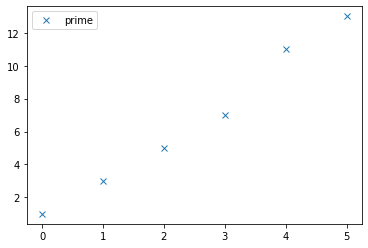

In [ ]:
## COMPLETE THIS CODE

# TODO: plot the "temperature" column of df_weather as a scatter-like plot against the index
# Use circle markers ("o") and no connecting line (linestyle="None")


<AxesSubplot:>

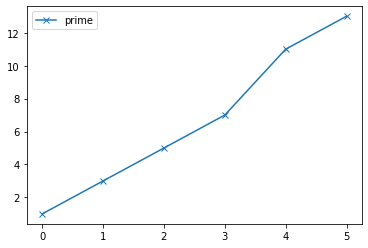

In [ ]:
## COMPLETE THIS CODE

# TODO: plot the same "temperature" column using df_weather.plot.line()
# but WITHOUT specifying linestyle="None"
# Observe: both markers and the connecting line appear


## Exercise 4: Dual Y-axis Plots with `twinx()`

**Objective**: Create a figure that displays two datasets with different scales using two y-axes.

When two quantities have very different units or magnitudes, you can use [`ax.twinx()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.twinx.html) to create a second Axes that shares the x-axis but has an independent y-axis on the right side. Match the axis label and tick colours to the corresponding dataset so the figure is easy to read.

The default matplotlib cycle colours `"C0"`, `"C1"`, etc. are useful for visually separating the two datasets.

**Task**: Using the monthly climate data provided below, create a dual y-axis figure:

- **Left y-axis**: monthly average temperature (°C) plotted as a line, coloured `"C0"`
- **Right y-axis**: monthly rainfall (mm) plotted as a bar chart, coloured `"C1"`
- Colour each y-axis label and its tick labels to match the data series
- Set the x-tick labels to month names and add a title

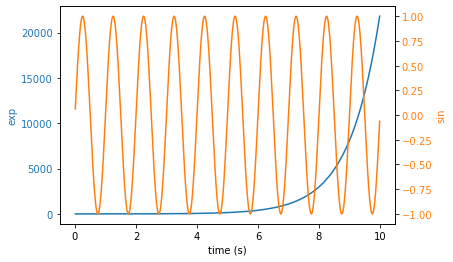

In [ ]:
# PROVIDED
import numpy as np
import matplotlib.pyplot as plt

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
x = np.arange(len(months))
temperature = [3, 4, 8, 12, 16, 20, 22, 21, 17, 12, 7, 4]      # °C
rainfall    = [52, 40, 47, 50, 55, 44, 47, 50, 54, 65, 58, 55]  # mm

In [ ]:
## COMPLETE THIS CODE

fig, ax1 = plt.subplots(figsize=(10, 5))

# TODO: plot temperature as a line on ax1 using colour "C0"
# Set the left y-axis label to "Temperature (°C)" with colour "C0"
# Set ax1 tick labels to colour "C0"

# TODO: create a second axes sharing the same x-axis with ax1.twinx()
ax2 = ...

# TODO: plot rainfall as a bar chart on ax2 using colour "C1"
# Set the right y-axis label to "Rainfall (mm)" with colour "C1"
# Set ax2 tick labels to colour "C1"

# TODO: set x-ticks to month names using ax1.set_xticks() and ax1.set_xticklabels()
# Add a title "Monthly Temperature and Rainfall"

plt.tight_layout()
plt.show()



## Exercise 5: Revision of Random Number Generation with NumPy

**Objective**: Practice creating and using a NumPy random number generator.

The modern NumPy approach is to create a *generator* object first, optionally with a fixed seed so results are reproducible:

```python
from numpy import random
rng = random.default_rng(seed=42)
```

You can then call methods on `rng` to draw samples:

- `rng.integers(low, high)` — a single random integer in `[low, high)`
- `rng.integers(low, high, size=n)` — an array of `n` random integers
- `rng.choice(seq)` — a single random element from a sequence
- `rng.choice(seq, size=k, replace=False)` — `k` unique elements (no repeats)
- `rng.shuffle(seq)` — shuffle a list **in-place**

**Tasks**:

1. Create a generator with `seed=99`.
2. Generate an array of 10 random integers between 1 and 100 (inclusive of 1, exclusive of 100).
3. From the list `["rock", "paper", "scissors"]`, simulate 5 random choices **with** replacement.
4. Shuffle the list `[1, 2, 3, 4, 5]` in-place and print it before and after.

In [ ]:
## COMPLETE THIS CODE

from numpy import random

# TODO: create a generator with seed=99
rng = ...

# TODO: generate an array of 10 random integers in [1, 100)
random_ints = ...
print(random_ints)

# TODO: simulate 5 random choices from ["rock", "paper", "scissors"] with replacement
moves = ...
print(moves)

# TODO: shuffle [1, 2, 3, 4, 5] in-place and print before and after
my_list = [1, 2, 3, 4, 5]
print("Before:", my_list)
# ... shuffle here ...
print("After: ", my_list)


## Exercise 6: DatetimeIndex and Filtering by Month

**Objective**: Work with a pandas `DatetimeIndex` to filter rows by a specific month.

When a DataFrame has a `DatetimeIndex`, you can access time components via `.index.month`, `.index.year`, `.index.day`, etc. These return integer arrays you can use as boolean filters.

**Tasks** — using the DataFrame provided below:

1. Confirm the index is a `DatetimeIndex` by printing `df.index`.
2. Extract **only the rows from March** (month 3) using `.index.month`.
3. Calculate the **mean value** for each month across all years. (*Hint*: group by `df.index.month` using `df.groupby(df.index.month).mean()`.)

In [ ]:
# PROVIDED
import pandas as pd
import numpy as np

dates = pd.date_range("2020-01-01", "2023-12-01", freq="MS")
values = np.random.default_rng(0).uniform(10, 30, size=len(dates))
df = pd.DataFrame({"temperature": values}, index=dates)
df.head()

In [ ]:
## COMPLETE THIS CODE

# TODO: print df.index — what type is it?

# TODO: filter df to only rows where the month is March (month == 3)
march_df = ...
print(march_df)

# TODO: compute the mean temperature for each calendar month across all years
monthly_means = ...
print(monthly_means)


## Exercise 7: NaN Propagation

**Objective**: Understand how `NaN` values behave in arithmetic operations on pandas Series.

Key rules:

- `NaN + number` → `NaN` (NaN is "viral" in arithmetic)
- Pandas *aggregation* functions (`.mean()`, `.sum()`, etc.) **skip** NaN by default
- You can fill NaN values before operating with `df["col"].fillna(value)`

**Tasks** — using the DataFrame provided below:

1. Add the two columns `"a"` and `"b"` together. Observe what happens where one value is `NaN`.
2. Add 100 to column `"b"`. What happens to the NaN entries?
3. Compute the mean of `"b"` — does pandas skip the NaN values?
4. Fill the NaN values in `"b"` with `0` first, then add 100. How does the result differ?

In [ ]:
# PROVIDED
import pandas as pd
import numpy as np

df_nan = pd.DataFrame({
    "a": [1.0, 2.0, 3.0, 4.0, 5.0],
    "b": [10.0, np.nan, 30.0, np.nan, 50.0],
})
df_nan

In [ ]:
## COMPLETE THIS CODE

# TODO: add columns "a" and "b" together — what happens where "b" is NaN?
print(df_nan["a"] + df_nan["b"])

# TODO: add 100 to column "b" — do NaN entries change?

# TODO: compute the mean of column "b" — does pandas skip NaN by default?

# TODO: fill NaN values in "b" with 0, then add 100 — compare the result



## Exercise 8: Finding a Minimum with `scipy.optimize`

**Objective**: Use `scipy.optimize.minimize_scalar` to find the minimum of a function, and restrict the search to a specific interval using bounds.

The lecture showed minimising $f(x) = x^2$ — a simple case where the minimum is at 0. In practice you often need to find a minimum inside a specific range. Passing `method="bounded"` and `bounds=(a, b)` restricts the search to $[a, b]$:

```python
from scipy.optimize import minimize_scalar
result = minimize_scalar(f, bounds=(0, 10), method="bounded")
print(result.x, result.fun)
```

**Tasks**:

1. Define the function $f(x) = \sin(x) + 0.1 \, x^2$.
2. Use `minimize_scalar` with `bounds=(0, 10)` and `method="bounded"` to find its minimum in $[0, 10]$.
3. Plot $f(x)$ over $[0, 10]$ and mark the minimum with a red dot. Label the axes and add a legend.

In [ ]:
## COMPLETE THIS CODE

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# TODO: define f(x) = sin(x) + 0.1 * x**2
def f(x):
    ...

# TODO: find the minimum of f in [0, 10] using minimize_scalar with method="bounded"
result = minimize_scalar(...)
print(f"Minimum value f(x) = {result.fun:.4f} at x = {result.x:.4f}")

# TODO: plot f(x) over [0, 10] and mark the minimum with a red dot
x = np.linspace(0, 10, 300)


## Exercise 9: Sampling from Distributions with `scipy.stats`

**Objective**: Use `scipy.stats` distribution objects to draw random samples and plot theoretical probability density functions (PDFs).

`scipy.stats` provides objects for many statistical distributions. Each object lets you:

- `.rvs(size=n, random_state=rng)` — draw `n` random samples
- `.pdf(x)` — evaluate the theoretical probability density at each point in `x`
- `.mean()`, `.std()` — get the theoretical mean and standard deviation

For example, a normal distribution with mean 5 and standard deviation 2:

```python
from scipy import stats
dist = stats.norm(loc=5, scale=2)

samples = dist.rvs(size=200, random_state=42)
```



**Tasks**:

1. Create a normal distribution with mean 10 and standard deviation 3. Draw 500 samples from it.

2. Plot a **normalised histogram** (`density=True`) of the samples.

3. On the same axes, overlay the theoretical PDF curve using `.pdf()` evaluated over a suitable range of `x` values.

4. Print the theoretical mean and standard deviation using `.mean()` and `.std()`, and compare them to `samples.mean()` and `samples.std()`.



In [ ]:
## COMPLETE THIS CODE

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats



dist = stats.norm(...)

print(f"Theoretical mean: {dist.mean():.2f},  sample mean: {samples.mean():.2f}")

# COMPLETE THIS CODE